# Langkah 1: Inisialisasi dataset

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from sklearn.datasets import make_blobs

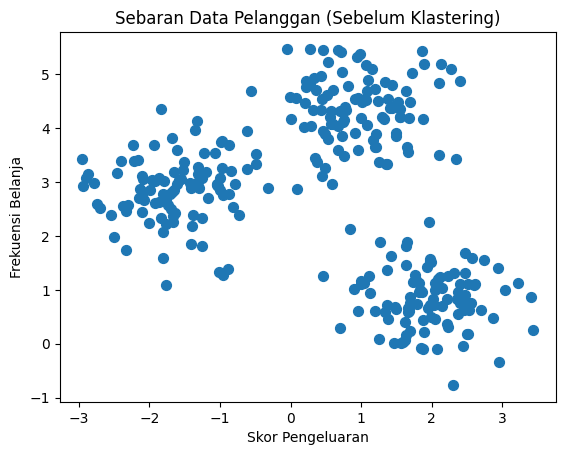

In [43]:
X_raw, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Konversi ke DataFrame agar mudah dibaca
df = pd.DataFrame(X_raw, columns=['Skor_Pengeluaran', 'Frekuensi_Belanja'])

# Visualisasi Data Mentah
plt.scatter(df['Skor_Pengeluaran'], df['Frekuensi_Belanja'], s=50)
plt.title("Sebaran Data Pelanggan (Sebelum Klastering)")
plt.xlabel("Skor Pengeluaran")
plt.ylabel("Frekuensi Belanja")
plt.show()

# Langkah 2: pre-processing(standarisasi)

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Langkah 3: mencari K optimal (metode elbow)

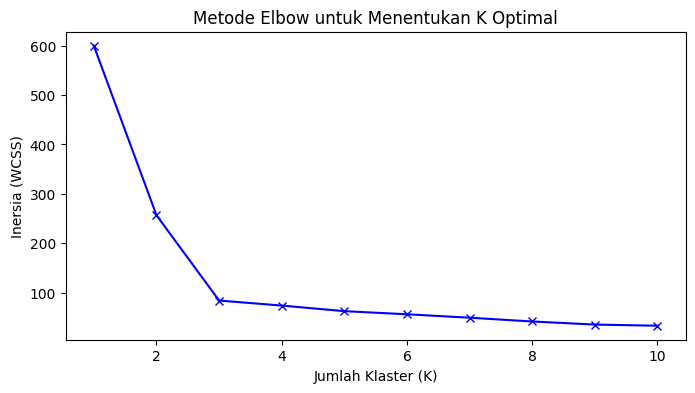

In [45]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting Elbow
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inersia (WCSS)')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.show()

# langkah 4: Final Clustering & Visualisasi

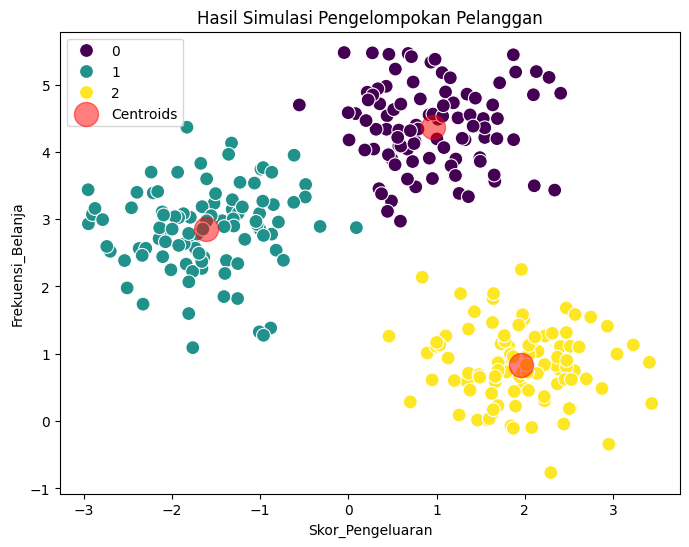

In [46]:
# Menjalankan K-Means dengan K=3
kmeans_final = KMeans(n_clusters=3, init='random', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Visualisasi Hasil Klastering
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Skor_Pengeluaran', y='Frekuensi_Belanja',
                hue='Cluster', palette='viridis', s=100)

# Plot Centroids
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, alpha=0.5, label='Centroids')
plt.title("Hasil Simulasi Pengelompokan Pelanggan")
plt.legend()
plt.show()

In [47]:
print(kmeans_final.cluster_centers_)

[[ 0.32370505  1.07648137]
 [-1.26344688  0.10883922]
 [ 0.93974182 -1.1853206 ]]


# Langkah 5: Validasi dengan Silhouette

In [48]:
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score untuk K=3: {score:.4f}")

Silhouette Score untuk K=3: 0.6592
